In [11]:
#Importing libraries
import h5py
import numpy as np
import re

# Ensure h5py is properly loaded/fix AttributeError: module 'h5py' has no attribute 'File'
import h5py._hl.files  # This ensures the File class is loaded
print("h5py version:", h5py.version.version)
print("h5py.File available:", hasattr(h5py, 'File'))

h5py version: 3.10.0
h5py.File available: True


In [12]:
# define which files of events are included in test / validation / training split
# the same split is done for each particle type
test_files_start = 0
test_files_stop = test_files_start+400
val_files_start = test_files_stop
val_files_stop = val_files_start+100
train_files_start = val_files_stop
train_files_stop = None # all remaining files are for training set
# train_files_stop = 500 # next 500 files are for training set

# define which particle labels to include 0=gamma 1=electron 2=muon 3=pi0
#labels = (0, 1, 2, 3) # 4 class
labels = (1,) # 1 class electrons
# labels = (2,) # 1 class muons
#labels = (1,2,) # 2 class e & mu

In [13]:
data_path = '/vols/hyperk/users/nprouse/WCTE/ML/WCTE_April2026/WCTE_1.5.2_April2026_0-1GeV_3M_e-_3M_mu-_medianT.h5'
f = h5py.File(data_path, "r")
root_files = np.array(f['root_files']).astype(str)
h5_file = h5py.File(data_path, 'r') #'r' is for read-only mode, wich means no changes can be made to the file's contents
for key, array in h5_file.items():
    print(f"{key:16s} array has shape {array.shape}")
    #If the string is shorter than 16 characters, it will be padded with spaces on the right to make it 16 characters long

angles           array has shape (6000000, 2)
energies         array has shape (6000000, 1)
event_hits_index array has shape (6000000,)
event_ids        array has shape (6000000,)
fully_contained  array has shape (6000000,)
hit_charge       array has shape (2388256816,)
hit_pmt          array has shape (2388256816,)
hit_time         array has shape (2388256816,)
labels           array has shape (6000000,)
positions        array has shape (6000000, 1, 3)
root_files       array has shape (6000000,)
veto             array has shape (6000000,)
veto2            array has shape (6000000,)


In [14]:
event_labels = np.array(h5_file['labels'])
label_set, label_counts = np.unique(event_labels, return_counts=True)
for label, count in zip(label_set, label_counts):
    print(f"Label {label} has {count} events")

Label 1 has 3000000 events
Label 2 has 3000000 events


In [15]:
# To determine the number of hits per event, take the difference between adjacent entries in the event hits index
events_hits_index = np.array(h5_file['event_hits_index'])
nhits = np.diff(events_hits_index, append=h5_file["hit_pmt"].shape[0])

In [16]:
fully_contained = np.array(h5_file["fully_contained"])
# Train on FC events with more than 10 hits
fc_selection = (nhits>10) & fully_contained

#ensure you are only picking electron events
electron_selection = np.array(h5_file['labels'])==0

muon_selection = np.array(h5_file['labels'])==1

cut = (fc_selection)

In [17]:
def atoi(text):
    return int(text) if text.isdigit() else text
# Sort by only the basename of the file, with natural sorting of numbers in the filename
def natural_keys(text):
    return [ atoi(c) for c in re.split(r'(\d+)', text.split('/')[-1]) ]

In [18]:
files_in_labels = {l: sorted(set(root_files[event_labels==l]), key=natural_keys) for l in labels}
idxs_in_files = {f: np.arange(i, i+c) for f,i,c in zip(*np.unique(root_files, return_index=True, return_counts=True))}

In [19]:
# select the events that are not cut
selected_idxs_in_files = {k: v[cut[v]] for k,v in idxs_in_files.items()}

In [20]:
for l, f in files_in_labels.items():
    print("label", l,"has", len(f),"files and ", sum([len(selected_idxs_in_files[i]) for i in f]), "selected indices")

label 1 has 1000 files and  975743 selected indices


In [21]:
split_files = {"test_idxs":  [f for l in labels for f in files_in_labels[l][test_files_start:test_files_stop]],
               "val_idxs":   [f for l in labels for f in files_in_labels[l][val_files_start:val_files_stop]],
               "train_idxs": [f for l in labels for f in files_in_labels[l][train_files_start:train_files_stop]]}
split_idxs = {k: [i for f in v for i in selected_idxs_in_files[f]] for k, v in split_files.items()}

In [22]:
for s in split_files.keys():
    print(s,"has", len(split_files[s]),"files and", len(split_idxs[s]),"indices")

test_idxs has 400 files and 390580 indices
val_idxs has 100 files and 97483 indices
train_idxs has 500 files and 487680 indices


In [23]:
len(split_idxs["train_idxs"])+ len(split_idxs["val_idxs"])+ len(split_idxs["test_idxs"])

975743

In [24]:
# Verify that all events are uniquely accounted for
all_indices = np.concatenate(list(split_idxs.values()))
print(len(event_labels))
print(len(event_labels[cut]))
print(len(all_indices))
print(len(set(all_indices)))

6000000
1709103
975743
975743


In [25]:
np.savez("/vols/hyperk/users/sc4422/dataset/medianT_split_index_list_e_FC.npz", 
         **split_idxs)

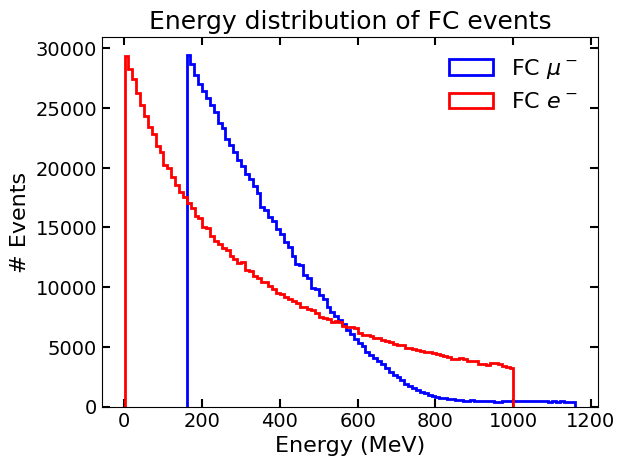

In [63]:
muon_cut = np.array(h5_file['labels'])==2 # muon cut
electron_cut = np.array(h5_file['labels'])==1 # electron cut
fc_cut = np.array(h5_file['fully_contained'])==True
energies= np.array(h5_file['energies'])
veto_cut = np.array(h5_file['veto'])==False # veto cut
veto2_cut = np.array(h5_file['veto2'])==False # veto2 cut


import matplotlib.pyplot as plt
plt.hist(energies[muon_cut 
                  & fc_cut 
                  #& veto_cut 
                  #& veto2_cut
                  ]
        ,bins=100,
        histtype='step',
        label='FC $\mu^-$',
        color='blue',
        linewidth=2
         )

plt.hist(energies[electron_cut 
                  & fc_cut 
                  #& veto_cut 
                  #& veto2_cut
                  ]
        ,bins=100,
        histtype='step',
        label='FC $e^-$',
        color='red',
        linewidth=2
         )

plt.xlabel('Energy (MeV)', size=16)
plt.ylabel('# Events', size=16)    
plt.title('Energy distribution of FC events', size=18)
plt.legend(fontsize=16, loc='best', frameon=False)
plt.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6, width=1.5, top=True, right=True)
plt.tick_params(axis='both', which='minor', direction='in', length=3, width=1, top=True, right=True)
plt.show()